In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

In [ ]:
trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform)

testloader = torch.utils.data.DataLoader(
    testset, batch_size=64, shuffle=False)

In [ ]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias = nn.Parameter(torch.empty(out_features))
        self.gate_scores = nn.Parameter(torch.empty(out_features, in_features))

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.weight, a=5**0.5)
        nn.init.zeros_(self.bias)
        nn.init.normal_(self.gate_scores, mean=0.0, std=0.01)

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        # Feature extraction
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Prunable layers
        self.fc1 = PrunableLinear(32 * 8 * 8, 128)
        self.fc2 = PrunableLinear(128, 10)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
model = Net().to(device)

In [ ]:
def sparsity_loss(model):
    loss = 0
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            loss += gates.sum()
    return loss

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

lambdas = [1e-5, 1e-4, 1e-3, 1e-2]

In [ ]:
"""epochs = 30

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        cls_loss = criterion(outputs, labels)
        sp_loss = sparsity_loss(model)

        loss = cls_loss + lambda_ * sp_loss
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")"""

'epochs = 30\n\nfor epoch in range(epochs):\n    model.train()\n    running_loss = 0\n\n    for images, labels in trainloader:\n        images, labels = images.to(device), labels.to(device)\n\n        optimizer.zero_grad()\n\n        outputs = model(images)\n        cls_loss = criterion(outputs, labels)\n        sp_loss = sparsity_loss(model)\n\n        loss = cls_loss + lambda_ * sp_loss\n        loss.backward()\n        optimizer.step()\n\n        running_loss += loss.item()\n\n    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")'

In [ ]:
"""model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print("Test Accuracy:", accuracy)"""

'model.eval()\ncorrect = 0\ntotal = 0\n\nwith torch.no_grad():\n    for images, labels in testloader:\n        images, labels = images.to(device), labels.to(device)\n\n        outputs = model(images)\n        _, predicted = torch.max(outputs, 1)\n\n        total += labels.size(0)\n        correct += (predicted == labels).sum().item()\n\naccuracy = 100 * correct / total\nprint("Test Accuracy:", accuracy)'

In [ ]:
"""def calculate_sparsity(model, threshold=1e-2):
    total = 0
    pruned = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            total += gates.numel()
            pruned += (gates < threshold).sum().item()

    return 100 * pruned / total"""

'def calculate_sparsity(model, threshold=1e-2):\n    total = 0\n    pruned = 0\n\n    for module in model.modules():\n        if isinstance(module, PrunableLinear):\n            gates = torch.sigmoid(module.gate_scores)\n            total += gates.numel()\n            pruned += (gates < threshold).sum().item()\n\n    return 100 * pruned / total'

In [ ]:
results = []

for lambda_ in lambdas:
    print(f"\nTraining with lambda = {lambda_}")

    model = Net().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.0005)
    criterion = nn.CrossEntropyLoss()

    # Training
    for epoch in range(30):
        model.train()
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            cls_loss = criterion(outputs, labels)
            sp_loss = sparsity_loss(model)

            loss = cls_loss + lambda_ * sp_loss
            loss.backward()
            optimizer.step()

    # Evaluation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    sparsity = calculate_sparsity(model)

    results.append((lambda_, accuracy, sparsity))


Training with lambda = 1e-05

Training with lambda = 0.0001

Training with lambda = 0.001

Training with lambda = 0.01


In [ ]:
print("Sparsity:", calculate_sparsity(model), "%")

Sparsity: 99.8174046404276 %


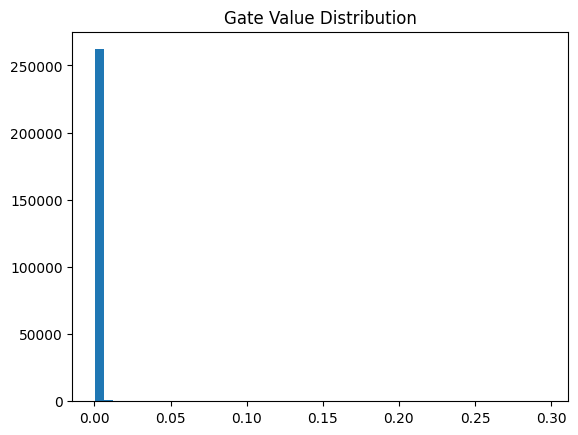

In [ ]:
all_gates = []

for module in model.modules():
    if isinstance(module, PrunableLinear):
        gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy().flatten()
        all_gates.extend(gates)

plt.hist(all_gates, bins=50)
plt.title("Gate Value Distribution")
plt.show()

In [ ]:
lambda_ = 1e-4
lambda_ = 1e-3
lambda_ = 1e-2

In [ ]:
print("\nFinal Results:")
print("Lambda\tAccuracy\tSparsity")

for l, acc, sp in results:
    print(f"{l}\t{acc:.2f}\t\t{sp:.2f}")


Final Results:
Lambda	Accuracy	Sparsity
1e-05	69.45		36.08
0.0001	68.54		55.86
0.001	67.76		85.34
0.01	62.92		99.82
